# Demo: substitu?n? ?ifra a kryptoanal?za

Notebook ukazuje povinn? funk?n? API, pohodln? objektov? API a fin?ln? konfiguraci pou?itou pro u?itelsk? ciphertexty. Neslou?? k op?tovn?mu zpracov?n? v?ech 60 ciphertext?; na??t? existuj?c? v?sledky z `outputs/` a prov?d? jen kr?tkou demonstra?n? uk?zku.

Pou??van? abeceda je `ABCDEFGHIJKLMNOPQRSTUVWXYZ_`, kde `_` p?edstavuje mezeru.

Fin?ln? konfigurace pro d?vkov? de?ifrov?n?:

```text
referen?n? matice: data/processed/TM_ref_krakatit.npy
restarts: 2
iterations na restart: 10000
celkem iterac? na ciphertext: 20000
polish_key: zapnut?
```


In [1]:
from pathlib import Path
import csv
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from substitution_cipher import (
    ALPHABET,
    SubstitutionCipher,
    get_bigrams,
    plausibility,
    prolom_substitute,
    substitute_decrypt,
    substitute_encrypt,
    transition_matrix,
)
from substitution_cipher.bigrams import load_matrix

KR_MATRIX_PATH = PROJECT_ROOT / 'data' / 'processed' / 'TM_ref_krakatit.npy'
COMBINED_MATRIX_PATH = PROJECT_ROOT / 'data' / 'processed' / 'TM_ref_combined.npy'
TM_ref = load_matrix(KR_MATRIX_PATH)

print('Projekt:', PROJECT_ROOT)
print('Matice:', KR_MATRIX_PATH.relative_to(PROJECT_ROOT))
print('Abeceda:', ALPHABET)


Projekt: D:\unicorn\python
Matice: data\processed\TM_ref_krakatit.npy
Abeceda: ABCDEFGHIJKLMNOPQRSTUVWXYZ_


## Povinn? funk?n? API

PDF zad?n? vy?aduje samostatn? funkce `substitute_encrypt`, `substitute_decrypt`, `get_bigrams`, `transition_matrix`, `plausibility` a `prolom_substitute`. Objektov? t??da `SubstitutionCipher` je pouze pohodln? fas?da nad stejnou implementac?.


In [2]:
key = 'DEFGHIJKLMNOPQRSTUVWXYZ_ABC'
plaintext = 'BYL_POZDNI_VECER'

ciphertext = substitute_encrypt(plaintext, key)
decrypted = substitute_decrypt(ciphertext, key)

bigrams = get_bigrams(plaintext)
absolute_matrix = transition_matrix(bigrams)
relative_matrix = absolute_matrix / absolute_matrix.sum()
score = plausibility(plaintext, relative_matrix)

found_key, found_plaintext, found_score = prolom_substitute(
    ciphertext,
    relative_matrix,
    5,
    ALPHABET,
)

print('Plaintext:', plaintext)
print('Ciphertext:', ciphertext)
print('Decrypted:', decrypted)
print('Round-trip OK:', decrypted == plaintext)
print('Po?et bigram?:', len(bigrams))
print('Matice:', relative_matrix.shape, 'suma', relative_matrix.sum())
print('Uk?zka prolom_substitute:', found_plaintext, found_score)


Plaintext: BYL_POZDNI_VECER
Ciphertext: EAOCSRBGQLCYHFHU
Decrypted: BYL_POZDNI_VECER
Round-trip OK: True
Po?et bigram?: 15
Matice: (27, 27) suma 1.0
Uk?zka prolom_substitute: EAOCSRBGQLCYHFHU -98.87510598012987


## Objektov? API

Doporu?en? pou?it? je p?es `SubstitutionCipher`. N?sleduj?c? bu?ka spou?t? jen kr?tkou demonstra?n? kryptoanal?zu na jednom u?itelsk?m ciphertextu. Fin?ln? b?h se prov?d? skriptem `scripts/decrypt_samples.py` s konfigurac? `2 x 10 000`.


In [3]:
sample_ciphertext_path = PROJECT_ROOT / 'data' / 'ciphertexts' / 'text_1000_sample_1_ciphertext.txt'

if sample_ciphertext_path.exists():
    sample_ciphertext = sample_ciphertext_path.read_text(encoding='utf-8').strip()
    cipher = SubstitutionCipher.from_matrix_file(KR_MATRIX_PATH)
    demo_result = cipher.crack(
        sample_ciphertext,
        iterations=100,
        restarts=1,
        seed=1,
        polish=False,
        progress_every=0,
    )
    print('D?lka ciphertextu:', len(sample_ciphertext))
    print('Demonstra?n? plaintext za??tek:', demo_result.plaintext[:120])
    print('Demonstra?n? sk?re:', demo_result.score)
else:
    print('Uk?zkov? ciphertext nen? k dispozici.')


Restart 1/1 best plausibility: -6789.140269238431
Overall best restart: 1, plausibility: -6789.140269238431
D?lka ciphertextu: 1000
Demonstra?n? plaintext za??tek: OUNV_ROANOD_JNOTOVTKORD_OM_VPOANOI_KCLOOVTIJU_STOK_OCTHOHYALOUEXTUNOD_MNOUS_UNOC_ALOZ_OHND_IOECTSOK_OCPK_OENHLUSTOJSTUNY
Demonstra?n? sk?re: -6789.140269238431


## Referen?n? matice

Projekt uchov?v? samostatnou matici z Krakatitu i kombinovanou matici z Krakatitu a V?lky s mloky. Fin?ln? konfigurace pou??v? Krakatit, proto?e benchmark na kontroln?m vzorku byl s touto matic? stabiln?j??.


In [4]:
for name, path in [('krakatit', KR_MATRIX_PATH), ('combined', COMBINED_MATRIX_PATH)]:
    if path.exists():
        matrix = load_matrix(path)
        print(name)
        print('  shape:', matrix.shape)
        print('  suma:', float(matrix.sum()))
        print('  obsahuje nuly:', bool((matrix == 0).any()))
    else:
        print(name, 'matice chyb?:', path)


krakatit
  shape: (27, 27)
  suma: 0.9999999999999999
  obsahuje nuly: False
combined
  shape: (27, 27)
  suma: 1.0
  obsahuje nuly: False


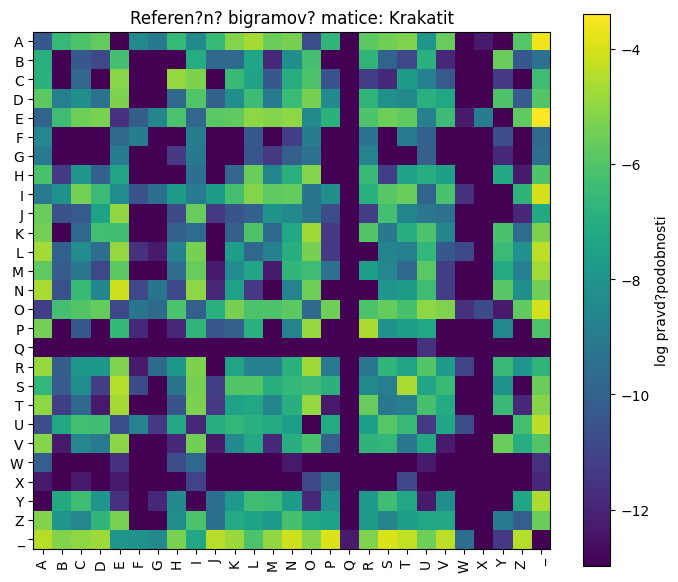

In [5]:
plt.figure(figsize=(7, 6))
plt.imshow(np.log(TM_ref), cmap='viridis')
plt.colorbar(label='log pravd?podobnosti')
plt.xticks(range(len(ALPHABET)), list(ALPHABET), rotation=90)
plt.yticks(range(len(ALPHABET)), list(ALPHABET))
plt.title('Referen?n? bigramov? matice: Krakatit')
plt.tight_layout()
plt.show()


## V?sledek benchmarku

Nejd?le?it?j?? nam??en? v?sledky pro zn?m? u?itelsk? kontroln? vzorek:

| Strategie | Matice | Pr?m?r | Minimum | P?esn? b?hy |
|---|---|---:|---:|---:|
| 1 x 20 000 | combined | 94,80 % | 92,20 % | 1/3 |
| 1 x 20 000 | krakatit | 93,60 % | 90,00 % | 1/3 |
| 2 x 10 000 | krakatit | 100,00 % | 100,00 % | 3/3 |
| 5 x 4 000 | krakatit | 100,00 % | 100,00 % | 3/3 |

Vybr?na byla strategie `2 x 10 000`, proto?e m?la stejnou p?esnost jako `5 x 4 000`, byla m?rn? rychlej?? a jej? konfigurace je jednodu???. Teacher plaintext a key byly pou?ity pouze pro n?sledn? vyhodnocen? benchmarku, ne b?hem hled?n?.

Tento v?sledek nen? univerz?ln? garance 100 % p?esnosti na v?ech nezn?m?ch textech.


In [6]:
benchmark_csv = PROJECT_ROOT / 'reports' / 'search_strategy_benchmark.csv'
benchmark_md = PROJECT_ROOT / 'reports' / 'search_strategy_benchmark.md'

print('Benchmark Markdown existuje:', benchmark_md.exists())
print('Benchmark CSV existuje:', benchmark_csv.exists())

if benchmark_csv.exists():
    with benchmark_csv.open(encoding='utf-8', newline='') as handle:
        rows = list(csv.DictReader(handle))
    print('Po?et benchmark ??dk?:', len(rows))
    if rows:
        best = max(rows, key=lambda row: float(row['matching_percent']))
        print('Nejlep?? ??dek:', best['strategy'], best['matrix'], best['matching_percent'])


Benchmark Markdown existuje: True
Benchmark CSV existuje: True
Po?et benchmark ??dk?: 30
Nejlep?? ??dek: 1x20000 krakatit 100.0


## Fin?ln? v?sledky z `outputs/`

Notebook pouze na??t? existuj?c? v?stupy. Pokud jste je?t? nespustili fin?ln? de?ifrov?n?, spus?te `run.bat` nebo p??kaz `python scripts\decrypt_samples.py --matrix data\processed\TM_ref_krakatit.npy --iterations 10000 --restarts 2`.


In [7]:
outputs_dir = PROJECT_ROOT / 'outputs'
plaintext_files = sorted(outputs_dir.glob('*_plaintext.txt')) if outputs_dir.exists() else []
key_files = sorted(outputs_dir.glob('*_key.txt')) if outputs_dir.exists() else []

print('Plaintext soubory:', len(plaintext_files))
print('Key soubory:', len(key_files))

sample_plaintext_path = outputs_dir / 'text_1000_sample_1_plaintext.txt'
sample_key_path = outputs_dir / 'text_1000_sample_1_key.txt'

if sample_plaintext_path.exists() and sample_key_path.exists():
    sample_plaintext = sample_plaintext_path.read_text(encoding='utf-8').strip()
    sample_key = sample_key_path.read_text(encoding='utf-8').strip()
    print('Uk?zka plaintextu:', sample_plaintext[:200])
    print('D?lka key:', len(sample_key))
else:
    print('V?stup pro text_1000_sample_1 zat?m nen? k dispozici.')


Plaintext soubory: 60
Key soubory: 60
Uk?zka plaintextu: _VOZEM_DO_NEHO_A_ZAS_MNE_BEZI_DO_CESTY__ZACHVELA_SE_TAK_KUDY_VPRAVO_NEBO_VLEVO_TEDY_JE_KONEC_PTAL_SE_TISE_POKYVLA_HLAVOU_TEDY_JE_KONEC_OTEVREL_DVIRKA_VYSKOCIL_Z_VOZU_A_POSTAVIL_SE_PRED_KOLA_JED_REKL_C
D?lka key: 27


## Vyhodnocen? zn?m?ho teacher sample

Soubor `data/teacher_example/text_1000_sample_1_plaintext.txt` slou?? pouze pro vyhodnocen? kvality v?sledku. B?hem de?ifrov?n? nen? algoritmu dostupn?.


In [8]:
teacher_plaintext_path = PROJECT_ROOT / 'data' / 'teacher_example' / 'text_1000_sample_1_plaintext.txt'
teacher_key_path = PROJECT_ROOT / 'data' / 'teacher_example' / 'text_1000_sample_1_key.txt'

if teacher_plaintext_path.exists() and sample_plaintext_path.exists():
    teacher_plaintext = teacher_plaintext_path.read_text(encoding='utf-8').strip()
    output_plaintext = sample_plaintext_path.read_text(encoding='utf-8').strip()
    matching_chars = sum(a == b for a, b in zip(output_plaintext, teacher_plaintext))
    print('Shodn? znaky:', matching_chars, '/', len(teacher_plaintext))
    print('Shoda [%]:', 100 * matching_chars / len(teacher_plaintext))
    print('Plaintext p?esn?:', output_plaintext == teacher_plaintext)
else:
    print('Teacher sample nebo v?stup zat?m nen? k dispozici.')

if teacher_key_path.exists() and sample_key_path.exists():
    teacher_key = teacher_key_path.read_text(encoding='utf-8').strip()
    output_key = sample_key_path.read_text(encoding='utf-8').strip()
    print('Key p?esn?:', output_key == teacher_key)


Shodn? znaky: 1000 / 1000
Shoda [%]: 100.0
Plaintext p?esn?: True
Key p?esn?: False


In [9]:
evaluation_csv = PROJECT_ROOT / 'reports' / 'evaluation_summary.csv'
if evaluation_csv.exists():
    with evaluation_csv.open(encoding='utf-8', newline='') as handle:
        rows = list(csv.DictReader(handle))
    print('Po?et ??dk? ve vyhodnocen?:', len(rows))
    teacher_rows = [row for row in rows if row.get('length') == '1000' and row.get('sample_id') == '1']
    if teacher_rows:
        print('??dek teacher sample:')
        for key, value in teacher_rows[0].items():
            print(f'  {key}: {value}')
else:
    print('evaluation_summary.csv zat?m neexistuje.')


Po?et ??dk? ve vyhodnocen?: 60
??dek teacher sample:
  length: 1000
  sample_id: 1
  plaintext_file: text_1000_sample_1_plaintext.txt
  key_file: text_1000_sample_1_key.txt
  plaintext_length: 1000
  key_valid: True
  plausibility: -5208.504696
  matches_teacher_example: True
  matching_chars: 1000
  matching_percent: 100.000000
  key_matches_teacher_example: False


## Omezen?

Metropolis-Hastings je n?hodn? algoritmus a r?zn? seedy mohou d?t r?zn? v?sledky. Krat?? texty jsou obt??n?j??, proto?e obsahuj? m?n? bigram?. N?kter? znaky se v ciphertextu nemus? objevit, tak?e cel? kl?? nemus? b?t jednozna?n? ur?iteln?. Bigramov? model hodnot? jazykovou pravd?podobnost, nikoli skute?nou znalost spr?vn?ho plaintextu.
